In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import ternary
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
from mpl_toolkits.mplot3d import Axes3D
from Functions_sirbu_loreto import *
from scipy.spatial.distance import pdist, squareform

# Generare una popolazione

The firt step is to generate a population of opinion vectors, of parameters $K$ , $N$ and entropy_treshold. The entropy threshold has to be chosen  starting from a desired initial overlap, according to the plots of pag. 12 of my master thesis.  
In the file 'MODELLO_SIRBU_LORETO' you can find the generation of the overlap - entropy plots. 

In [4]:
K = 3
N = 300
S_trash = 0.7

population = generate_population(K , N,S_trash)
o = calculate_total_overlap(population) 

In [7]:
print(o)

0.4070666218911873


/Users/alicenappa/miniconda3/lib/python3.13/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


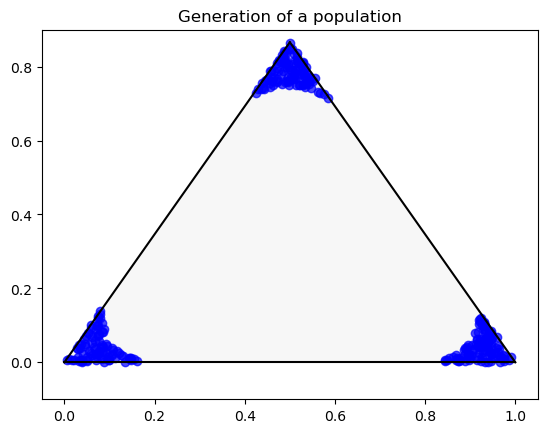

In [8]:
scale = 1

fig, tax = ternary.figure(scale=scale)
tax.boundary()
tax.scatter(population, marker='o', color='blue', alpha = 0.7)
tax.set_title('Generation of a population')
tax.show()

# POPUTATION EVOLUTION

## 1. PEER INTERACTION

### The system evolving with peer interaction only is ruled by the initial overlap. The only parameter controlling the final state of the population is the overlap. 


Ci sono due files a seconda se consideriamo il sistema open minded oppure no.  Vediamo prima quello normale del paper di vittorio che si chiama Functions_sirbu_loreto

Ci sono evolve population 1 ed evolve population 2, l'unica differenza è che nell'1 ci salviamo anche gli step dell'interazione (per creare il network), tipo chi interagisce con chi e con che score di overlap etc. In evolve_population_2 invece non lo salvo, serve a vedere la phase transition (è più snello e gira in meno tempo)

* time = step di evoluione
* pop_iniz = popolazione di vettori da far evolvere
* alpha , eps = parametri di loreto
* evolve_population( pop_iniz , time , eps, alpha)

Le funzioni si basano su una funzione di base messa dentro alle funzioni di evoluzione che è: $\textbf{interact\_individuals}:$ vediamo un esempio, ricordando che è solo l'individuo uno a cambiare

In [9]:
individuo_1 = [0.7 , 0.1, 0.2]
individuo_2 = [0.2, .4, .4]
eps = 0.01
alpha = 0.0167

In [10]:
i1_post_interaction, o_ij, p_agree = interact_individuals(individuo_1,individuo_2, eps, alpha )

l= 2
delta= 0.0167


In [11]:
print( 'L overlap tra i due vettori è' , o_ij , ' La probabilità di agreement è' , p_agree, 'Il vettore 1 post interazione', i1_post_interaction)

L overlap tra i due vettori è 0.5896919751144688  La probabilità di agreement è 0.5796919751144688 Il vettore 1 post interazione [0.70835 0.10835 0.1833 ]


In [12]:
sum(i1_post_interaction)

np.float64(1.0)

Durante l'evoluzione, gli step evolutivi sono salvati dentro 'storico' che è un dizionario cui chiavi sono gli step temporali e cui valori sono le popolazioni intere salvate step by step (si può modificare ovviamente, dipende da che ti interessa monitorare.)

In [5]:
population = generate_population(K , N, 1.5)

pop_finale   , storico ,ps_agree, overlaps = evolve_population_1(population, 100000, 0.1 , 0.0167)

/Users/alicenappa/miniconda3/lib/python3.13/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


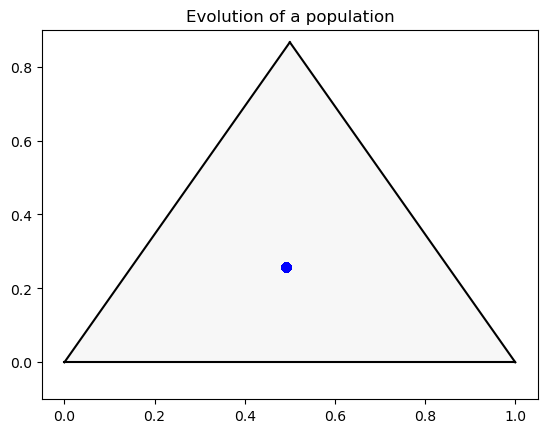

In [6]:
scale = 1

fig, tax = ternary.figure(scale=scale)
tax.boundary()
tax.scatter(pop_finale, marker='o', color='blue', alpha = 0.7)
tax.set_title('Evolution of a population')
tax.show()

## 2. EXTERNAL INFORMATION INTERACTION

* PI = PROBABILITA DI INTERAGIRE AD OGNI STEP CON LA FONTE ESTERNA
* a = 0.333.  POLARIZZAZIONE DELLA FONTE ESTERNA
* K  = 3
* I = external_info(3,0.8) This generate the external info matrix with the desired polarization
* time = 100000 
* pop = generate_population( K ,300, 1.2)
* pop_evoluta_with_info ,storico = evolve_population_with_info( np.array(pop) , time , 0.1, 0.0167 , I , PI)    

### $\downarrow$ cambia i valori di a in questa cella e vedi che succede all'evoluzione della popolazione

In [7]:
PI = 0.5
a = 0.5
K  = 3
I = external_info(3,a)
time = 100000
pop = generate_population( K ,300, 1.2)
pop_evoluta_with_info ,storico = evolve_population_with_info( np.array(pop) , time , 0.1, 0.0167 , I , PI)    

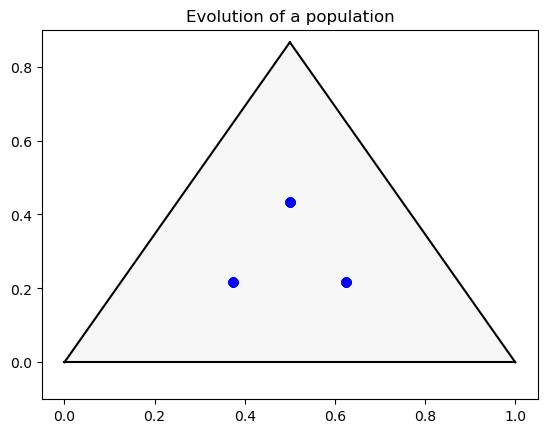

In [8]:
scale = 1

fig, tax = ternary.figure(scale=scale)
tax.boundary()
tax.scatter(pop_evoluta_with_info, marker='o', color='blue', alpha = 0.7)
tax.set_title('Evolution of a population')
tax.show()

* $\textbf{interact\_with\_info}$  In this the individual interacts with the source it has the highest overlap with. ( with probability PI ). The evolution function of this is $\textbf{evolve\_population\_with\_info}$
* $\textbf{evolve\_population\_with\_random\_info}$ here interaction is made with a casual source of information with PI , the corresponding function is $\textbf{evolve\_population\_with\_random\_info}$
* At the end of the file there are many combinations of interact with info and peer, with random info and peer etc. Make or choose the desired combination 

# 3. OPEN MINDEDNESS

In [10]:
from Functions_OPEN_MINDEDNESS import *

Nella funzione $\textbf{interact\_individuals\_om}$ cambiamo l'interazinoe inserendo tutte le regole di bracci (DIRETTAMENTE CON MEMORIA)

In queste funzioni abbiamo due dizionari che si occupano di salvare e monitorare il processo, $\textbf{storico}$ e $\textbf{storico\_interaction}$

* storico_interaction[i1_index][t].append([interaction, distance , i2_index ,w ]) questo si salva per ogni individuo interaction type, distance, i2 , w per ogni volta che i1 interagisce durante lo storico. 
* storico salva popolazione ad ogni t come prima 


* $\textbf{evolve\_population\_with\_info\_and\_peer\_openm}$ $\rightarrow$ è la funzione di evoluzione in cui: 

1.  Estrae casualmente tre individui dalla popolazione ($i_1, i_2, i_3$).I
2. Peer interaction (ma open minded):L'individuo $i_1$ interagisce con $i_2$.Viene calcolato il valore $w$ di $i_1$ basandosi sulla sua cronologia recente (finestra mu).L'opinione di $i_1$ viene aggiornata tramite interact_individuals, che decide se l'agente agirà in maniera open minded o normale.
3. External info interaction :L'individuo $i_3$ viene esposto alla matrice di informazione esterna $I$.Con una probabilità $PI$, l'agente $i_3$ confronta la propria opinione con le fonti esterne e si sposta verso quella con overlap maggiore (si può cambiare). 
4. Registrazione Dati: Lo stato della popolazione e i dettagli dell'interazione vengono salvati nei dizionari storico e storico_interaction.